In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('dataset.csv')
print(df.columns)
df.shape

Index(['index', 'having_IPhaving_IP_Address', 'URLURL_Length',
       'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting',
       'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State',
       'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token',
       'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH',
       'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover',
       'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord',
       'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page',
       'Statistical_report', 'Result'],
      dtype='object')


(11055, 32)

In [4]:
df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [3]:
print(df.isnull().sum())
print(f"\nTarget count: {df['Result'].value_counts()}")

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [23]:
# split data before training
X = df.drop(columns = ['index', 'Result'])
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# find best hyperparameters for our models
def print_k_accuracy(): # helper function to visualize k neighbors relationship with model accuracy
    k = list(range(1,25, 2))
    acc_vals = []
    print("----Printing  k values with accuracy score for knn model----")
    for i in k:
        knn = KNeighborsClassifier(n_neighbors = i)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        acc_vals.append(accuracy)
        print(f"Accuracy score for {i}: {accuracy}")
    plt.plot(k, acc_vals, marker = 'o')  
    plt.xlabel("K-neighbors")
    plt.ylabel("Accuracy")
    plt.title("KNN accuracy per k neighbors")
    print("\n\n")
    return

def best_params(algo):
    if algo == 'lr':
        print("No parameters supported for Linear Regression\n\n")
        return
    elif algo == 'LinearSVC':
        param_grid = {'loss': ['hinge', 'squared_hinge']}
        model = LinearSVC(max_iter = 10000)
    elif algo == 'SVC':
        param_grid = {'kernel': ['rbf', 'linear', 'poly']}
        model = SVC(max_iter = 10000)
    elif algo == 'knn':
        print_k_accuracy()
        return
    elif algo == 'tree':
        param_grid = {'max_depth': [None, 3, 5, 7, 10],
                      'min_samples_split': [2, 5, 10],
                      'min_samples_leaf': [1, 2, 4],
                      'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
                      'criterion': ['gini', 'entropy']}
        model = DecisionTreeClassifier()
    elif algo == 'RF':
        param_grid = {'n_estimators': [50, 100, 150, 200, 250],
                      'max_depth': [None, 3, 5, 10, 20],
                      'min_samples_split': [2, 5, 10],
                      'max_features': ['sqrt', 'log2', None]}
        model = RandomForestClassifier()
    else:
        print("Model not supported")
        return
    grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-5, # using all but 4 cores to increase speed but also not exhaust our pc resources
    verbose=1)

    if algo != 'RF' and algo != 'tree': # use scaled data if using LogisticRegression, LinearSVC, SVC, or knn
        grid_search.fit(X_train_scaled, y_train)
    else:
        grid_search.fit(X_train, y_train)
    print(f"The best parameters for {algo} are: {grid_search.best_params_}\n\n")

No parameters supported for Linear Regression


Fitting 5 folds for each of 2 candidates, totalling 10 fits


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


The best parameters for LinearSVC are: {'loss': 'hinge'}


Fitting 5 folds for each of 3 candidates, totalling 15 fits
The best parameters for SVC are: {'kernel': 'rbf'}


----Printing  k values with accuracy score for knn model----
Accuracy score for 1: 0.9571902321374737
Accuracy score for 3: 0.9430208019294544
Accuracy score for 5: 0.933675007536931
Accuracy score for 7: 0.9285498944829665
Accuracy score for 9: 0.9297558034368405
Accuracy score for 11: 0.9339764847753994
Accuracy score for 13: 0.9303587579137775
Accuracy score for 15: 0.926439553813687
Accuracy score for 17: 0.9225203497135966
Accuracy score for 19: 0.9189026228519747
Accuracy score for 21: 0.9170937594211637
Accuracy score for 23: 0.9164908049442267



Fitting 5 folds for each of 360 candidates, totalling 1800 fits
The best parameters for tree are: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


Fitting 5 folds for each of 225 candidates, totalling 1125

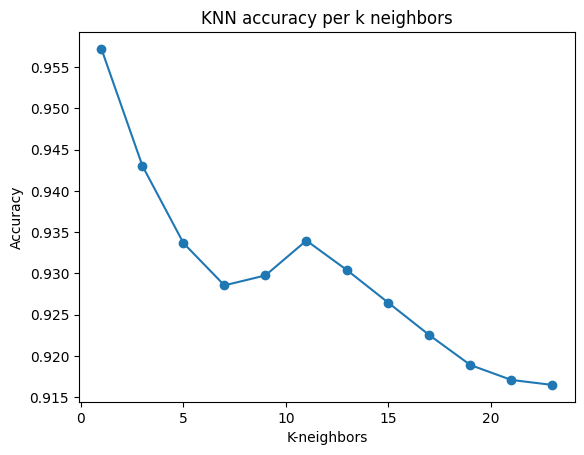

In [49]:
models = ['lr', 'LinearSVC', 'SVC', 'knn', 'tree', 'RF']
for m in models:
    best_params(m)

In [59]:
# function to train model based on selected algorithm using best hyperparameters found from best_params(model)
# if hyperparameters appear on best_params(model) but not on train_model(algo), then the default hyperparameters were returned by best_params(model),
# and there's no need to specify them again when calling the model

def train_model(algo):
    if algo == 'lr':
        model = LogisticRegression(max_iter = 10000)
    elif algo == 'LinearSVC':
        model = LinearSVC(max_iter = 20000, loss ='hinge') # couldn't get model to converge so stopped at 20K iterations
    elif algo == 'SVC':
        model = SVC(max_iter = 10000, kernel = 'rbf')
    elif algo == 'knn':
        model = KNeighborsClassifier(n_neighbors = 3)
    elif algo == 'tree':
        model = DecisionTreeClassifier(criterion = 'entropy')
    elif algo == 'RF':
        model = RandomForestClassifier(max_features ='log2')
    else:
        print("Model not supported")
        return

    if algo != 'RF' and algo != 'tree': # use scaled data if using LogisticRegression, LinearSVC, SVC, or knn
        model = model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
    else:
        model = model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precision: {round(precision, 3)}")
    print(f"Recall is: {round(recall, 3)}")
    print(f"Accuracy is: {round(accuracy, 3)}")
    print(f"F1-Score is: {round(f1, 3)}")
    if algo != 'RF' and algo != 'tree' and algo != 'knn': print(f"Model converges at {model.n_iter_} iterations")
    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)

    return [model, precision, recall, accuracy, f1]

In [51]:
print("Logistic Regression model performance metrics")
LR = train_model('lr')

Logistic Regression model performance metrics
Precision: 0.931
Recall is: 0.932
Accuracy is: 0.922
F1-Score is: 0.931
Model converges at [20] iterations
Train accuracy: 0.9313776169552856
Test accuracy: 0.9219173952366596


In [57]:
print("LinearSVC model performance metrics")
linearSVC_model = train_model('LinearSVC')

LinearSVC model performance metrics
Precision: 0.928
Recall is: 0.94
Accuracy is: 0.924
F1-Score is: 0.934
Model converges at 20000 iterations
Train accuracy: 0.9299560609976738
Test accuracy: 0.9243292131444076


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [64]:
print("SVM model performance metrics")
svc_model = train_model('SVC')

SVM model performance metrics
Precision: 0.947
Recall is: 0.96
Accuracy is: 0.947
F1-Score is: 0.953
Model converges at [2895] iterations
Train accuracy: 0.959033341948824
Test accuracy: 0.9466385287910762


In [65]:
print("KNN performance metrics")
knn = train_model('knn')

KNN performance metrics
Precision: 0.945
Recall is: 0.956
Accuracy is: 0.943
F1-Score is: 0.95
Train accuracy: 0.976608942879297
Test accuracy: 0.9430208019294544


In [66]:
print("Tree Classifier model performance metrics")
tree = train_model('tree')

Tree Classifier model performance metrics
Precision: 0.961
Recall is: 0.969
Accuracy is: 0.96
F1-Score is: 0.965
Train accuracy: 0.990695270095632
Test accuracy: 0.9599035272836901


In [63]:
print("Random Forest model performance metrics")
RF = train_model('RF')

Random Forest model performance metrics
Precision: 0.962
Recall is: 0.981
Accuracy is: 0.967
F1-Score is: 0.971
Train accuracy: 0.990695270095632
Test accuracy: 0.9668375037684654


In [68]:
# highest accuracy model
models = [LR, linearSVC_model, svc_model, knn, tree, RF]
models = sorted(models, key=lambda x: x[3], reverse = True) # x[3] to sort based on model accuracy
print(models[0][0])

RandomForestClassifier(max_features='log2')


In [69]:
import pickle
import joblib

RF = RF[0]
with open("model.pkl", "wb") as f:
    pickle.dump(RF, f)